# LINMA2471 - Optimization Models and Methods II
## Project: Markowitz Portfolio Optimization

---

<p></p>

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
import utils
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)
importlib.reload(utils)

from models import *
from methods import *
from data import *
from utils import *

### Data

In [2]:
processor = DataProcessor()
data = processor.get_optimization_data()

In [18]:
w0 = get_initial_portfolio(data['mu'].shape[0])
mu = data['mu']
sigma = data['sigma']
lam = 0.5
c = 0.01
w_prev = w0
model_non_smooth = NonSmoothMarkowitzModel({
    "mu": mu,
    "sigma": sigma,
    "lam": lam,
    "c": c,
    "w_prev":w_prev
})
model = SmoothMarkowitzModel({
    "mu": mu,
    "sigma": sigma,
    "lam": lam,
})
L = model.lipschitz_constant()


import cvxpy as cp


n = len(mu)
w = cp.Variable(n)

objective = (
    0.5 * cp.quad_form(w, sigma)
    - lam * mu @ w
    + c * cp.norm1(w - w_prev)
)

# ADD SIMPLEX CONSTRAINTS! This was missing before.
constraints = [cp.sum(w) == 1, w >= 0]

problem = cp.Problem(cp.Minimize(objective), constraints)
problem.solve(solver=cp.ECOS)

w_opt = w.value
print(f"CVXPY optimal value: {model_non_smooth.f(w_opt)}")
f_ref = model_non_smooth.f(w_opt)
print(f"f_ref = {f_ref:.8f}")

CVXPY optimal value: -0.0002424491454438678
f_ref = -0.00024245


### Subgradient

Estimated M (subgradient bound): 0.2646

=== Comparing Diminishing Step Size with different α₀ ===

Running with α₀ = 1e-02...
  Converged: True, Iterations: 48429, Value: -0.00024145

Running with α₀ = 1e-03...
  Converged: True, Iterations: 94002, Value: -0.00024145

Running with α₀ = 1e-04...
  Converged: False, Iterations: 100000, Value: 0.00463466


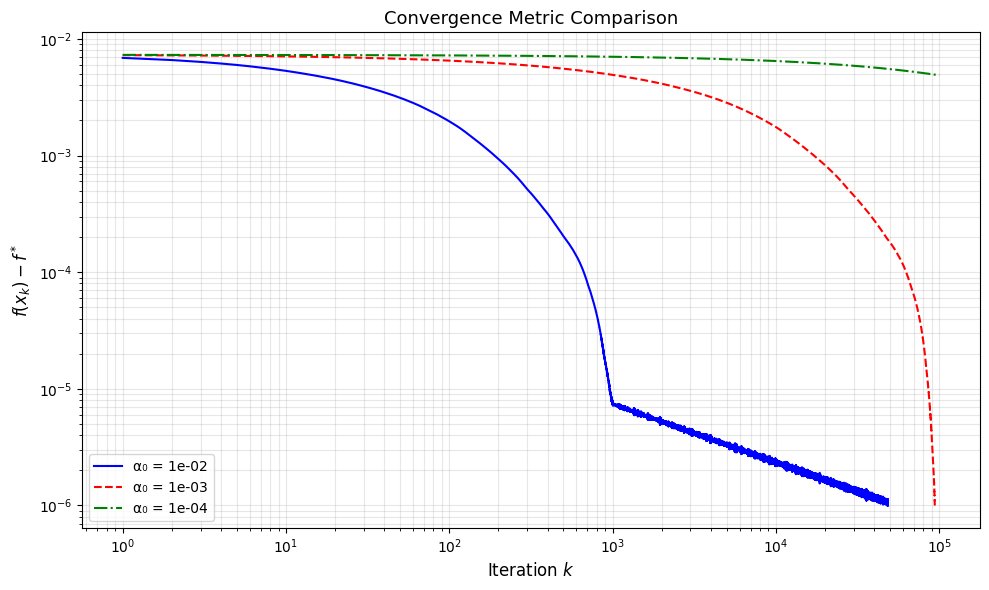

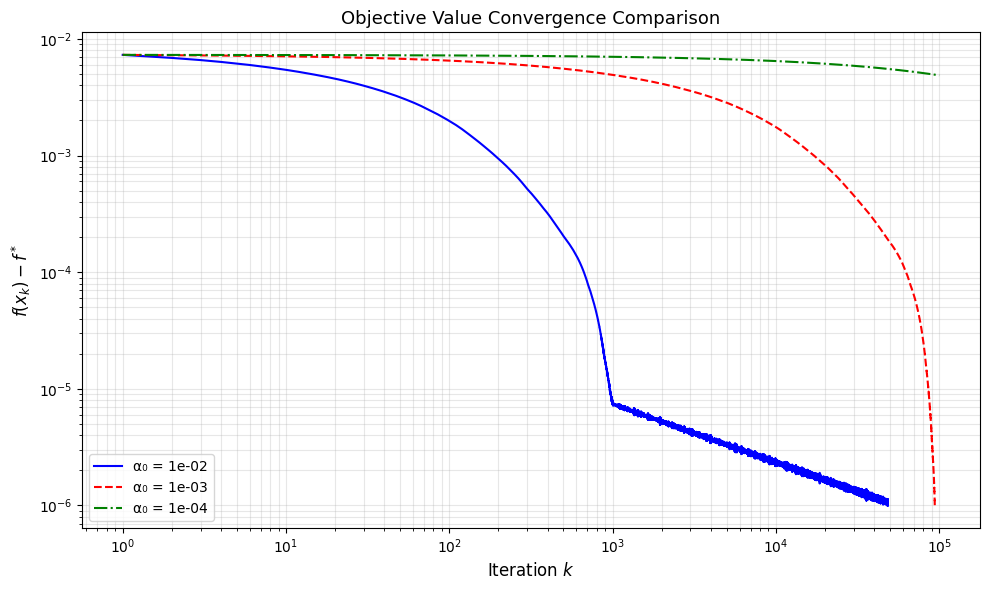

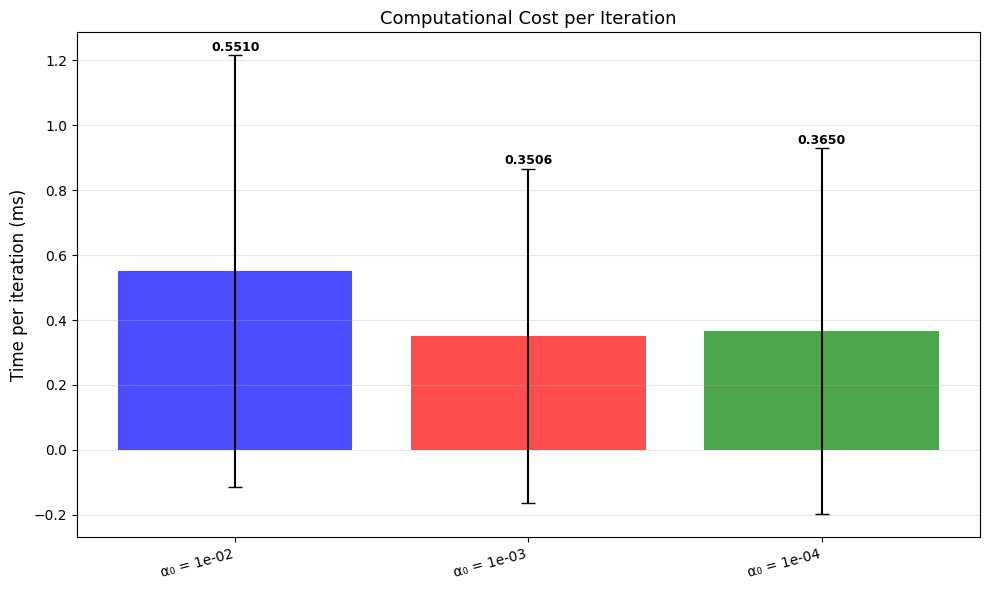


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
α₀ = 1e-02                         0.5510     0.6648     0.0000     0.0000    20.0231
α₀ = 1e-03                         0.3506     0.5149     0.0000     0.0000    34.0040
α₀ = 1e-04                         0.3650     0.5639     0.0000     0.0000    33.9944

Method                          Total Time (s)   Iterations
------------------------------------------------------------
α₀ = 1e-02                             26.6835        48429
α₀ = 1e-03                             32.9606        94002
α₀ = 1e-04                             36.4972       100000


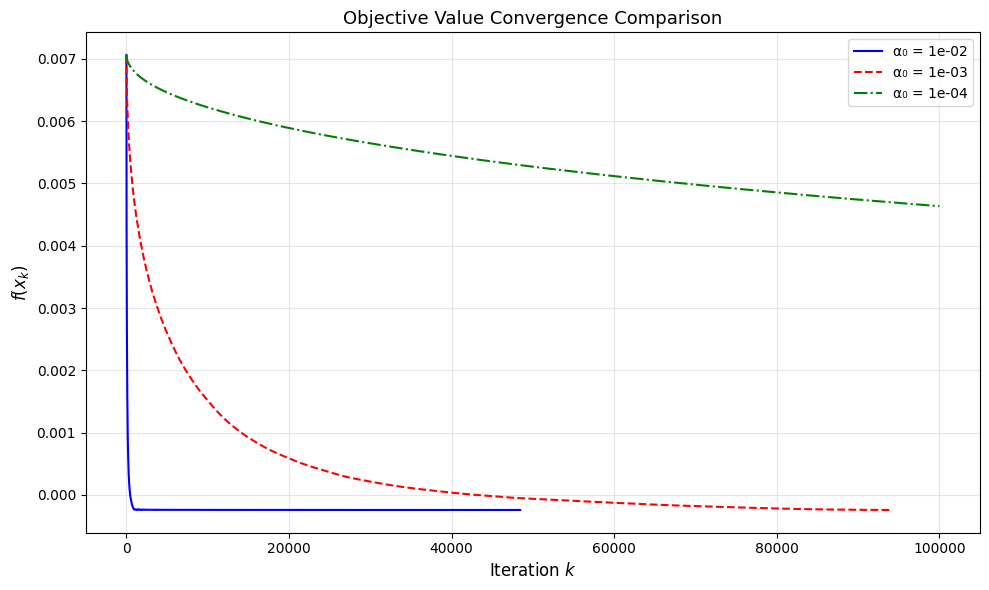

In [4]:
w0 = get_initial_portfolio(data['mu'].shape[0], method='random')
M = L + np.linalg.norm(mu) + c * np.sqrt(len(mu))
print(f"Estimated M (subgradient bound): {M:.4f}")

# === Graph 1: Constant step size with different tol/M**2 ===
# print("\n=== Comparing Constant Step Size with different tol/M² ===")
# results_constant = {}
# tol_values = [1e-3, 1e-4, 1e-5, 1e-6 , 1e-7]

# for tol in tol_values:
#     step_size = tol / M**2
#     label = f'α = {tol:.0e}/M²'
#     print(f"\nRunning with {label}...")
    
#     method = ProjectedSubgradientMethod({
#         'step_size': step_size,
#         'step_size_rule': 'constant',
#         'max_iter': 700000,
#         'tol': tol,
#     }, ValuePerformanceIndicator_with_ref(f_ref=f_ref))
    
#     result = method.optimize(model_non_smooth, w0.copy())
#     results_constant[label] = result
#     print(f"  Converged: {result['converged']}, Iterations: {result['iterations']}, Value: {result['value']:.8f}")

# compare_methods(results_constant, method_name="Subgradient_constant_stepsize", 
#                 metric_used='function_with_ref', f_ref=f_ref, save_dir="../figures")

print("\n=== Comparing Diminishing Step Size with different α₀ ===")
results_diminishing = {}
initial_step_sizes = [1e-2,1e-3 , 1e-4]

for alpha0 in initial_step_sizes:
    label = f'α₀ = {alpha0:.0e}'
    print(f"\nRunning with {label}...")
    
    method = ProjectedSubgradientMethod({
        'step_size': alpha0,
        'step_size_rule': 'diminishing',
        'max_iter': 100000,
        'tol': 1e-6,
    }, ValuePerformanceIndicator_with_ref(f_ref=f_ref))
    
    result = method.optimize(model_non_smooth, w0.copy())
    results_diminishing[label] = result
    print(f"  Converged: {result['converged']}, Iterations: {result['iterations']}, Value: {result['value']:.8f}")

compare_methods(results_diminishing, method_name="Subgradient_diminishing_stepsize", 
                metric_used='function_with_ref', f_ref=f_ref, save_dir="../figures")

### Plot 2: Complexity vs Precision ε

For each precision $\varepsilon$, measure the number of iterations $T$ needed to reach $\varepsilon$-accuracy.
Compare with theoretical complexity $O(1/\varepsilon^2)$.

=== Plot 2: Complexity vs precision ε ===
  ε=1.00e-02: reached in 1 iterations
  ε=1.39e-03: reached in 13 iterations
  ε=1.93e-04: reached in 165 iterations
  ε=2.68e-05: reached in 1493 iterations
  ε=3.73e-06: reached in 11338 iterations
  ε=5.18e-07: reached in 83127 iterations


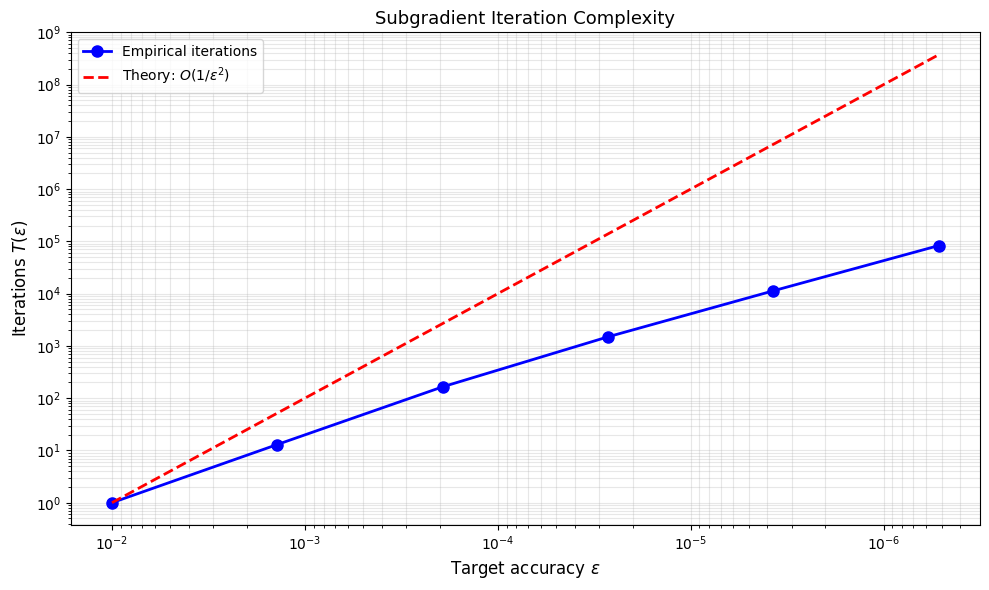

{'epsilons': array([1.00000000e-02, 1.38949549e-03, 1.93069773e-04, 2.68269580e-05,
        3.72759372e-06, 5.17947468e-07]),
 'iterations': array([    1,    13,   165,  1493, 11338, 83127])}

In [8]:
# Define range of epsilons to test
epsilons = np.logspace(-2, -8, 8)  # de 1e-2 à 1e-6


# Plot 2: Complexity vs Precision

plot_subgradient_complexity(model_non_smooth, w0, f_ref, M, epsilons, max_iter=100000,
                                 method_name='Subgradient', save_dir="../figures")

30.54817718645065


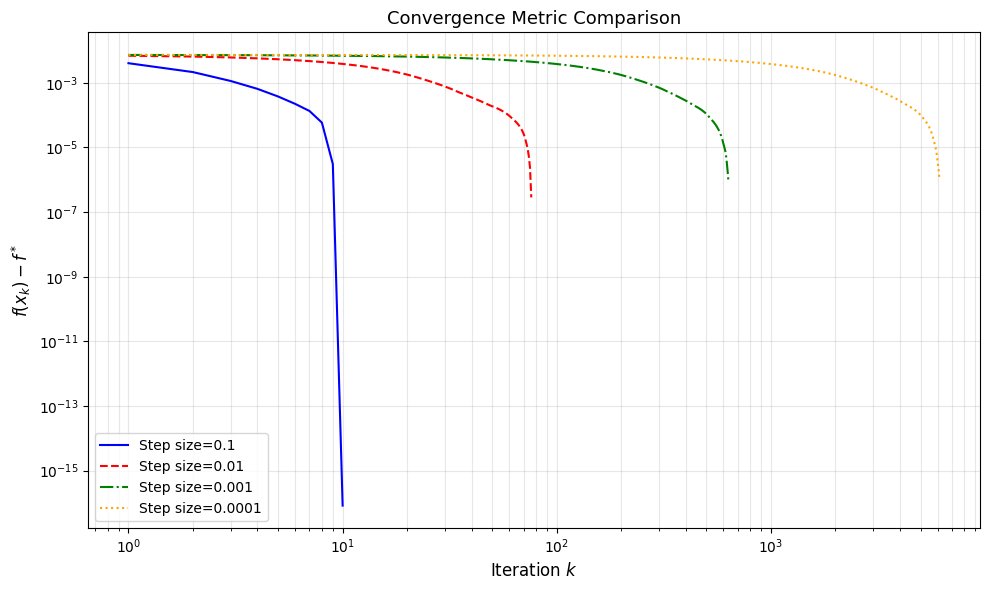

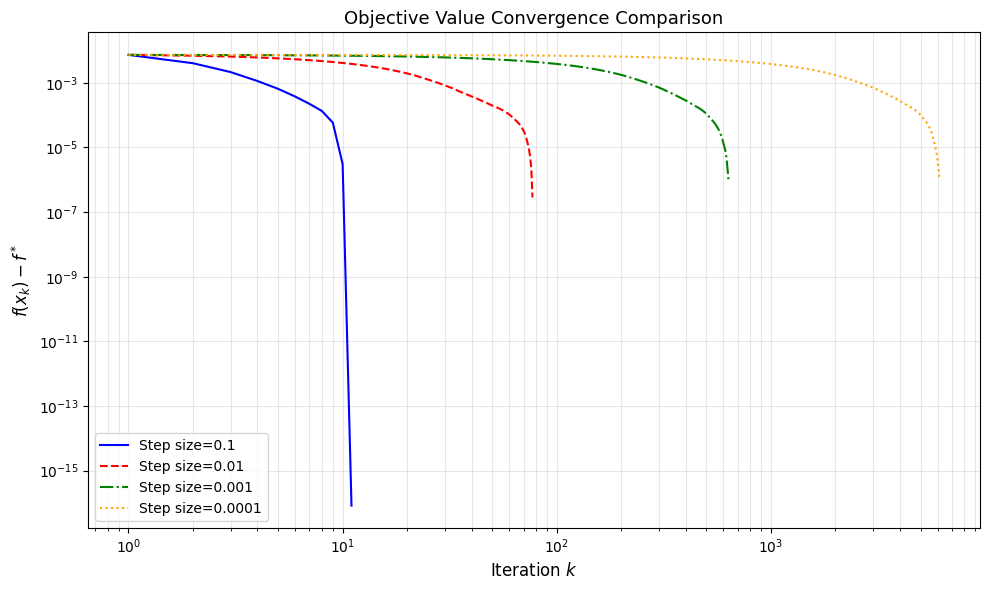

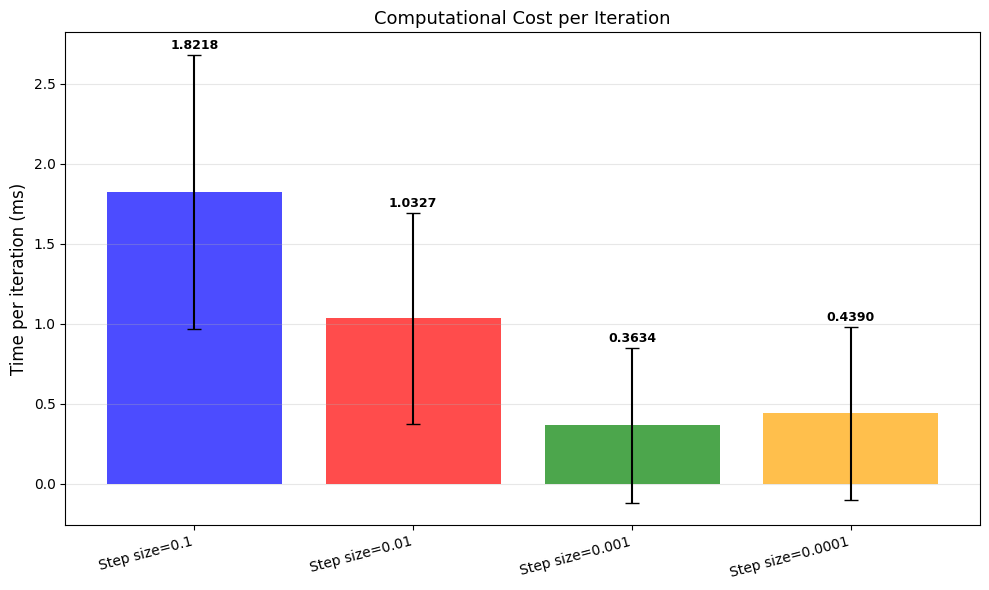


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Step size=0.1                      1.8218     0.8587     1.9979     0.9899     4.0019
Step size=0.01                     1.0327     0.6614     0.9993     0.0000     3.0036
Step size=0.001                    0.3634     0.4826     0.0000     0.0000     1.5078
Step size=0.0001                   0.4390     0.5405     0.0000     0.0000     5.6274

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Step size=0.1                           0.0182           10
Step size=0.01                          0.0785           76
Step size=0.001                         0.2297          632
Step size=0.0001                        2.6859         6119


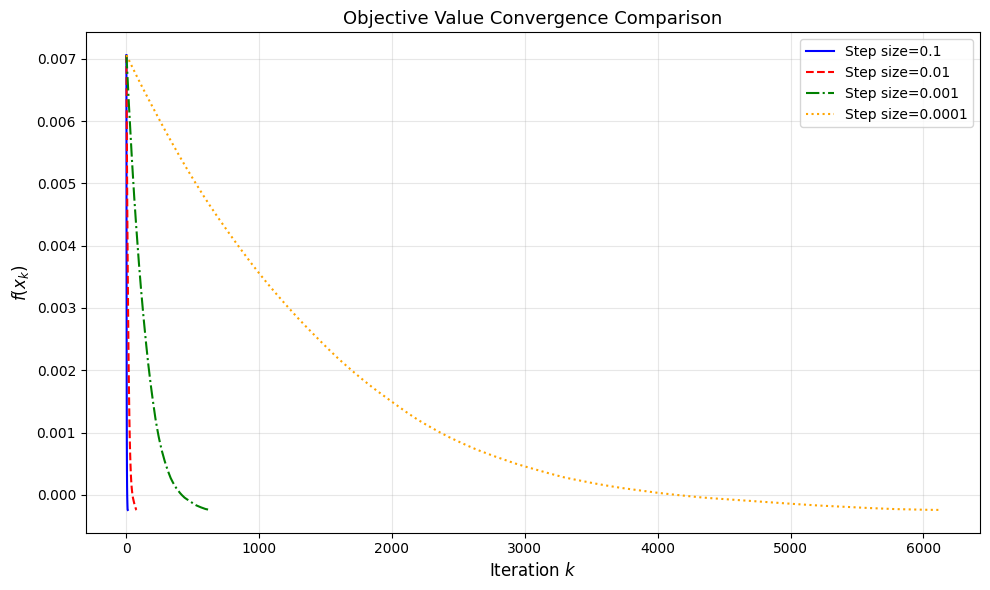

In [12]:
# Proximal Gradient Method
# Use the SAME w0 as subgradient method for fair comparison

# method_proximal = ProximalGradientMethod({
#     'step_size': 0.01,           # Use 1/L for convergence guarantee
#     'max_iter': 10000,
#     'tol': 1e-6,
# }, ValuePerformanceIndicator_with_ref(f_ref=f_ref))

# # Use the SAME w0 as the subgradient method (don't redefine it!)
# result_ProximalGradient = method_proximal.optimize(model_non_smooth, w0)

# print("Keys disponibles:", result_ProximalGradient.keys())
# print(f"Converged: {result_ProximalGradient['converged']}")
# print(f"Iterations: {result_ProximalGradient['iterations']}")
# print(f"Final objective value: {result_ProximalGradient['value']}")


# Plot convergence
results_3 = {}
print(1/L)
step_size = [1e-1 , 1e-2 , 1e-3 , 1e-4 ]
for i in step_size:
    method_proximal = ProximalGradientMethod({
        'step_size': i,           # Use 1/L for convergence guarantee
        'max_iter': 10000,
        'tol': 1e-6,
    }, ValuePerformanceIndicator_with_ref(f_ref=f_ref))

    result = method_proximal.optimize(model_non_smooth, w0)
    results_3[f"Step size={i}"] = result

compare_methods(results_3, method_name="Proximal_Gradient_stepsize", 
                metric_used='function_with_ref', f_ref=f_ref, save_dir="../figures")



Measuring complexity for: Proximal Gradient
  tol=1.00e-02: 1 iterations
  tol=2.15e-03: 1 iterations
  tol=4.64e-04: 1 iterations
  tol=1.00e-04: 1 iterations
  tol=2.15e-05: 1 iterations
  tol=4.64e-06: did not converge in 10000 iterations
  tol=1.00e-06: did not converge in 10000 iterations
  tol=2.15e-07: did not converge in 10000 iterations
  tol=4.64e-08: did not converge in 10000 iterations
  tol=1.00e-08: did not converge in 10000 iterations


ValueError: not enough values to unpack (expected 3, got 2)

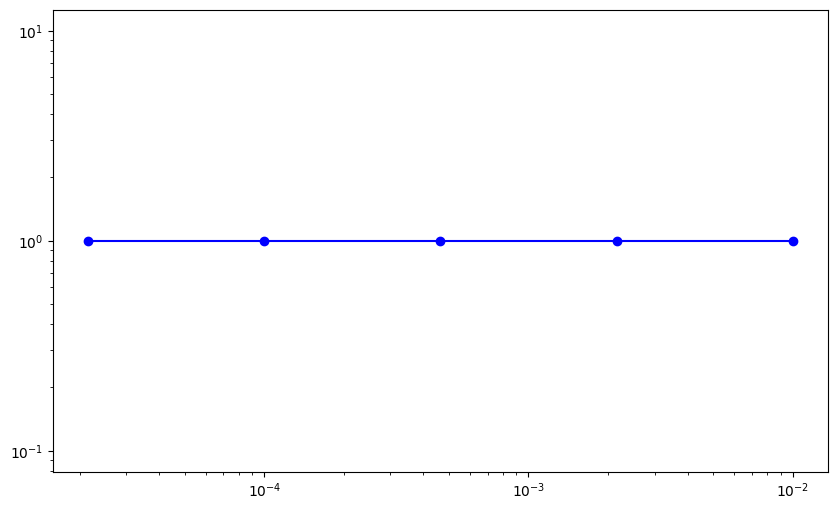

In [16]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-8

result_complexity = measure_iteration_complexity(
    methods_config=[(ProximalGradientMethod,{
        'step_size': 1/L,
        'max_iter': 10000,
        'tol': 1e-8,
    } , "Proximal Gradient")],
   
    model=model_non_smooth,
    w0=w0,
    tolerances=tolerances,
    theoretical_rates=[(1, r'$O(\epsilon^{-1})$')],

    plot_name='ProximalGradientMethod',
    save_dir='../figures',
    metrics='function_with_ref',
    f_ref=f_ref 
)

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 33
Final objective value: -0.000242


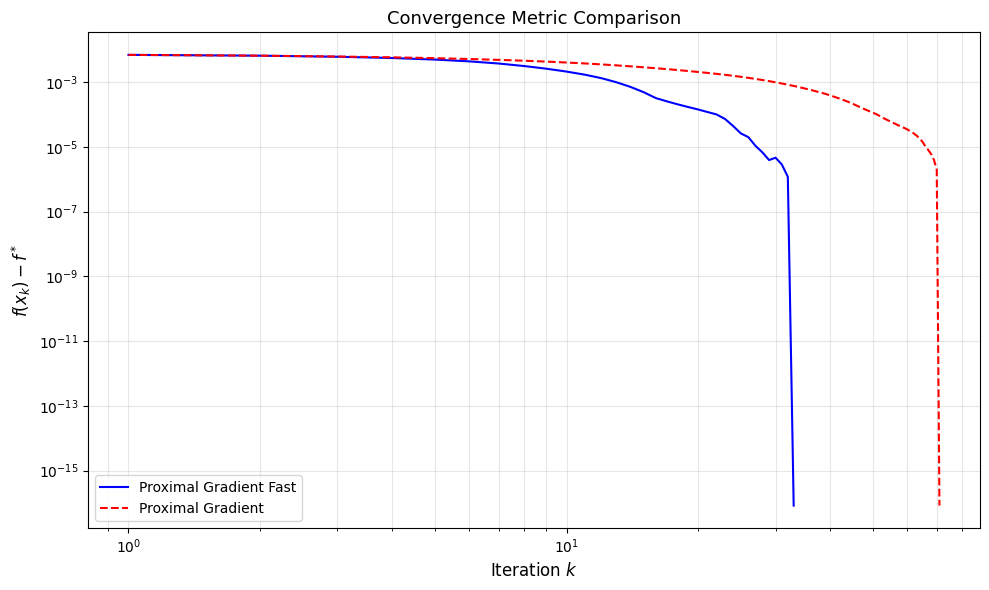

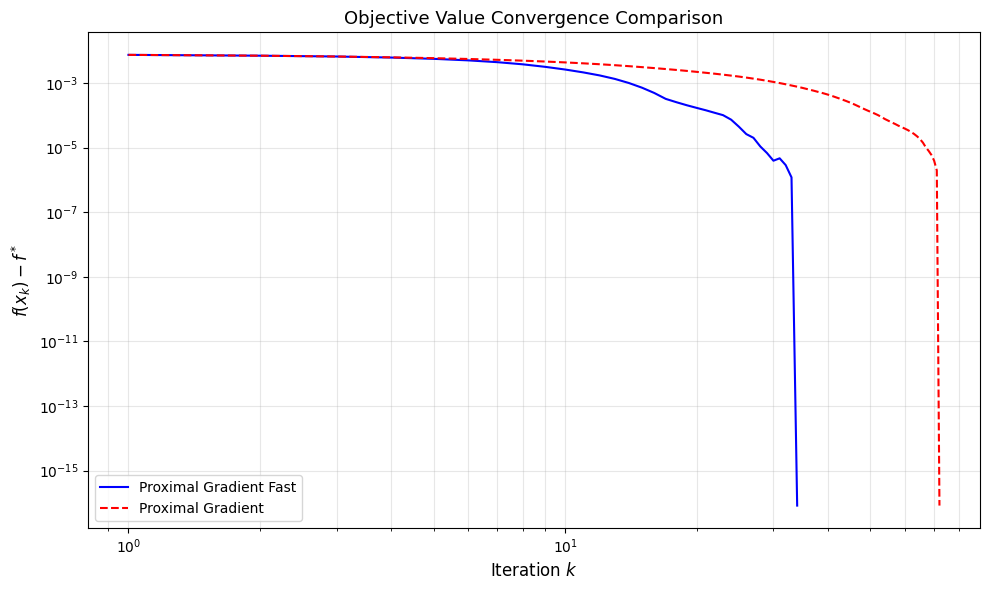

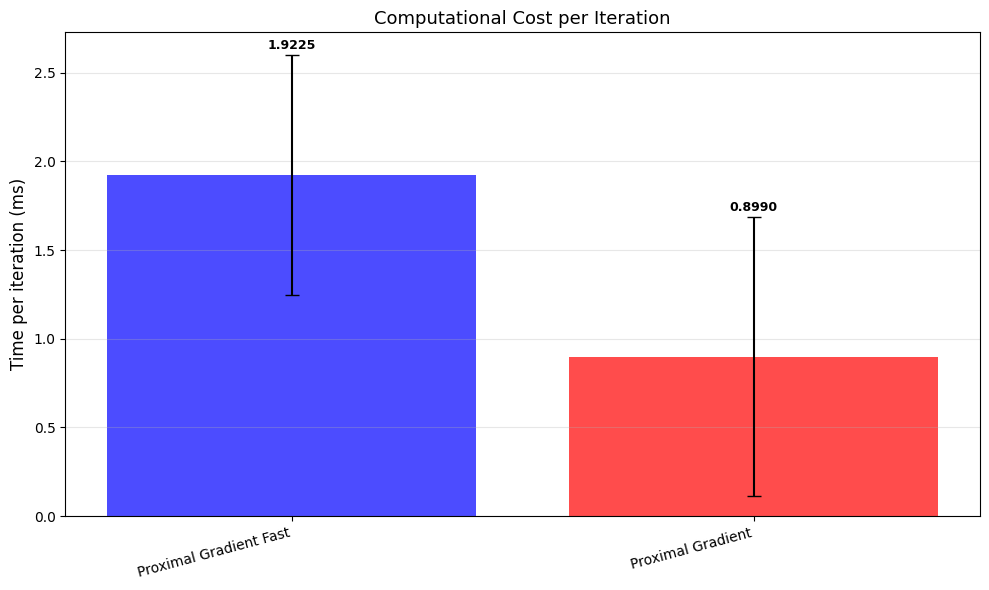


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Proximal Gradient Fast             1.9225     0.6754     1.9989     0.9894     3.0713
Proximal Gradient                  0.8990     0.7877     0.9992     0.0000     3.0248

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Proximal Gradient Fast                  0.0634           33
Proximal Gradient                       0.0638           71


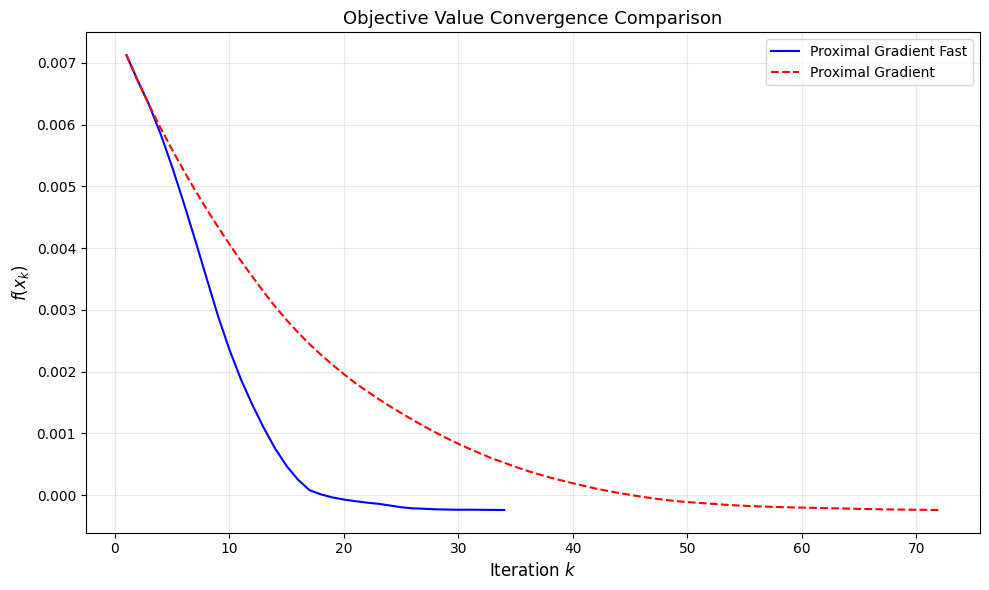

In [27]:
# Constant step size only converges to a neighborhood of the optimum

method1 = ProximalGradientMethod({
    'step_size': 0.01,              # Initial step size α_0
    'max_iter': 10000,
    'tol': 1e-8,
}, ValuePerformanceIndicator_with_ref(f_ref))
method2 = ProximalGradientMethod_fast({
    'step_size': 0.01,              # Initial step size α_0
    'max_iter': 10000,
    'tol': 1e-8,
}, ValuePerformanceIndicator_with_ref(f_ref))

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0] , method="random")

# Optimize portfolio on training data
result1_ProjectedSubgradientMethod = method2.optimize(model_non_smooth, w0)
result2_ProjectedSubgradientMethod = method1.optimize(model_non_smooth, w0)
print("Keys disponibles:", result1_ProjectedSubgradientMethod.keys())
print(f"Converged: {result1_ProjectedSubgradientMethod['converged']}")
print(f"Iterations: {result1_ProjectedSubgradientMethod['iterations']}")
print(f"Final objective value: {result1_ProjectedSubgradientMethod['value']:.6f}")

# Plot convergence
compare_methods(
    {
        "Proximal Gradient Fast": result1_ProjectedSubgradientMethod,
        "Proximal Gradient": result2_ProjectedSubgradientMethod
    },
    method_name="Proximal_Gradient_vs_Fast",
    metric_used='function_with_ref',
    f_ref=f_ref,
    save_dir="../figures"
)




Measuring complexity for: Proximal Gradient fast
  tol=1.00e-02: 1 iterations
  tol=3.46e-03: 32 iterations
  tol=1.19e-03: 50 iterations
  tol=4.12e-04: 75 iterations
  tol=1.43e-04: 93 iterations
  tol=4.92e-05: 128 iterations
  tol=1.70e-05: 163 iterations
  tol=5.88e-06: 184 iterations
  tol=2.03e-06: 199 iterations
  tol=7.02e-07: 199 iterations
  tol=2.42e-07: 199 iterations
  tol=8.38e-08: 199 iterations
  tol=2.89e-08: 199 iterations
  tol=1.00e-08: 199 iterations


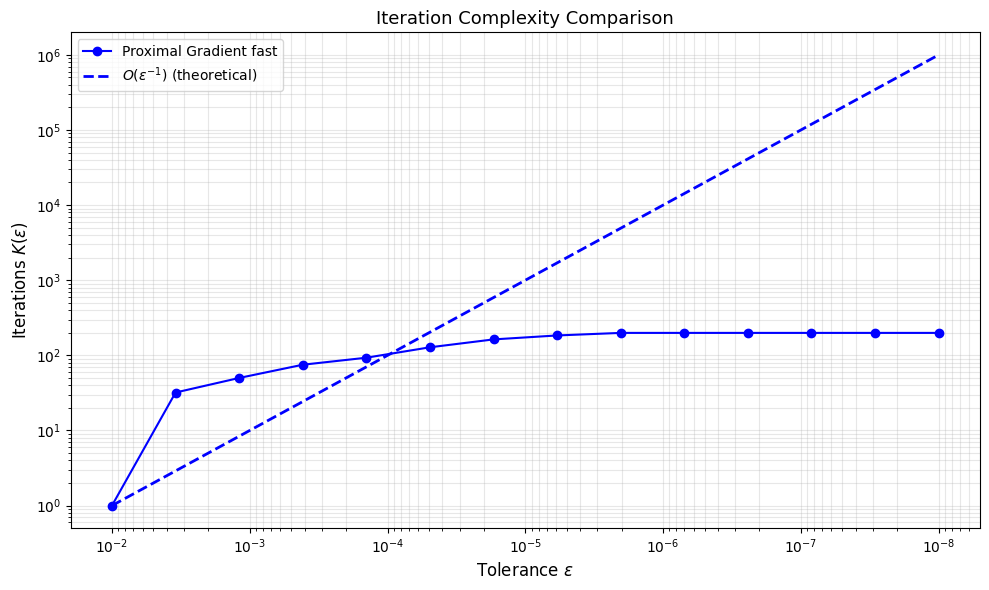

In [ ]:
tolerances = np.logspace(-2, -8, 14)  # de 1e-2 à 1e-8

result_complexity = measure_iteration_complexity(
    methods_config=[(ProximalGradientMethod_fast,{
        'step_size': 1/L,
        'max_iter': 10000,
    }, "Proximal Gradient fast")],
    model=model_non_smooth,
    w0=w0,
    tolerances=tolerances,
    theoretical_rates=[(1, r'$O(\epsilon^{-1})$' , "--")],
    plot_name='ProximalGradientMethod_fast',
    save_dir='../figures',
    metrics='function_with_ref',
    f_ref=f_ref 
)

### Impact of Transaction Cost Parameter c

Analyzing how the transaction cost parameter $c$ affects:
1. **Convergence behavior** - Does higher $c$ slow down convergence?
2. **Optimal portfolio** - How does $c$ affect portfolio turnover and sparsity?
3. **Trade-off** - Risk-return vs transaction costs

In [ ]:
# === Analysis of Transaction Cost Parameter c ===
# Using Proximal Gradient Method (best method)

w0 = get_initial_portfolio(data['mu'].shape[0], method='random')
w_prev = w0.copy()  # Previous portfolio for transaction costs

# Test different values of c
c_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.5]

results_c = {}
optimal_portfolios = {}
portfolio_metrics = []

for c_val in c_values:
    print(f"\n=== c = {c_val} ===")
    
    # Create model with this c value
    model_c = NonSmoothMarkowitzModel({
        "mu": mu,
        "sigma": sigma,
        "lam": lam,
        "c": c_val,
        "w_prev": w_prev
    })
    
    # Compute reference optimal value with CVXPY
    w_cvx = cp.Variable(len(mu))
    if c_val > 0:
        obj = 0.5 * cp.quad_form(w_cvx, sigma) - lam * mu @ w_cvx + c_val * cp.norm1(w_cvx - w_prev)
    else:
        obj = 0.5 * cp.quad_form(w_cvx, sigma) - lam * mu @ w_cvx
    prob = cp.Problem(cp.Minimize(obj), [cp.sum(w_cvx) == 1, w_cvx >= 0])
    prob.solve(solver=cp.ECOS)
    f_ref_c = model_c.f(w_cvx.value)
    
    # Run Proximal Gradient Method
    method = ProximalGradientMethod({
        'step_size': 0.01,
        'max_iter': 10000,
        'tol': 1e-8,
    }, ValuePerformanceIndicator_with_ref(f_ref=f_ref_c))
    
    result = method.optimize(model_c, w0.copy())
    results_c[f'c = {c_val}'] = result
    optimal_portfolios[c_val] = result['x']
    
    # Compute portfolio metrics
    w_opt = result['x']
    turnover = np.sum(np.abs(w_opt - w_prev))  # Total turnover
    sparsity = np.sum(w_opt < 1e-4)  # Number of zero weights
    expected_return = mu @ w_opt
    variance = w_opt @ sigma @ w_opt
    transaction_cost = c_val * turnover
    
    portfolio_metrics.append({
        'c': c_val,
        'turnover': turnover,
        'sparsity': sparsity,
        'expected_return': expected_return,
        'variance': variance,
        'transaction_cost': transaction_cost,
        'iterations': result['iterations'],
        'final_value': result['value']
    })
    
    print(f"  Iterations: {result['iterations']}, Final value: {result['value']:.8f}")
    print(f"  Turnover: {turnover:.4f}, Sparsity: {sparsity}/{len(mu)}")
    print(f"  Expected return: {expected_return:.6f}, Variance: {variance:.6f}")

# Compare convergence for different c values
compare_methods(results_c, method_name="ProximalGradient_impact_c", 
                metric_used='function_with_ref', f_ref=f_ref, save_dir="../figures")

In [ ]:
# === Visualization of the impact of c ===

import pandas as pd
df_metrics = pd.DataFrame(portfolio_metrics)
print("\n=== Portfolio Metrics Summary ===")
print(df_metrics.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Turnover vs c
axes[0, 0].plot(df_metrics['c'], df_metrics['turnover'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Transaction cost c', fontsize=12)
axes[0, 0].set_ylabel('Portfolio Turnover', fontsize=12)
axes[0, 0].set_title('Turnover vs Transaction Cost', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Sparsity vs c
axes[0, 1].plot(df_metrics['c'], df_metrics['sparsity'], 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Transaction cost c', fontsize=12)
axes[0, 1].set_ylabel('Number of zero weights', fontsize=12)
axes[0, 1].set_title('Portfolio Sparsity vs Transaction Cost', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Iterations vs c
axes[0, 2].plot(df_metrics['c'], df_metrics['iterations'], 'go-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Transaction cost c', fontsize=12)
axes[0, 2].set_ylabel('Iterations to converge', fontsize=12)
axes[0, 2].set_title('Convergence Speed vs Transaction Cost', fontsize=13)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Expected return vs Variance (efficient frontier shift)
axes[1, 0].scatter(df_metrics['variance'], df_metrics['expected_return'], 
                   c=df_metrics['c'], cmap='viridis', s=100, edgecolors='black')
for i, row in df_metrics.iterrows():
    axes[1, 0].annotate(f"c={row['c']}", (row['variance'], row['expected_return']), 
                        textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[1, 0].set_xlabel('Variance (Risk)', fontsize=12)
axes[1, 0].set_ylabel('Expected Return', fontsize=12)
axes[1, 0].set_title('Risk-Return Trade-off for Different c', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Transaction cost component vs c
axes[1, 1].plot(df_metrics['c'], df_metrics['transaction_cost'], 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Transaction cost c', fontsize=12)
axes[1, 1].set_ylabel('Transaction Cost Component', fontsize=12)
axes[1, 1].set_title('Transaction Cost in Objective', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Portfolio weights distribution for different c
n_assets = len(mu)
x_pos = np.arange(n_assets)
width = 0.15
for i, (c_val, w_opt) in enumerate(optimal_portfolios.items()):
    # Only show top 10 assets for clarity
    top_indices = np.argsort(w_opt)[-10:]
    axes[1, 2].bar(np.arange(10) + i*width, w_opt[top_indices], width, 
                   label=f'c={c_val}', alpha=0.8)
axes[1, 2].set_xlabel('Top 10 Assets', fontsize=12)
axes[1, 2].set_ylabel('Weight', fontsize=12)
axes[1, 2].set_title('Portfolio Weights (Top 10 assets)', fontsize=13)
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/impact_transaction_cost_c.svg', bbox_inches='tight', format='svg')
plt.show()

print("\n=== Key Insights ===")
print(f"• Higher c reduces turnover: from {df_metrics['turnover'].iloc[0]:.4f} (c=0) to {df_metrics['turnover'].iloc[-1]:.4f} (c={c_values[-1]})")
print(f"• Sparsity increases with c: from {df_metrics['sparsity'].iloc[0]} to {df_metrics['sparsity'].iloc[-1]} zero weights")
print(f"• Convergence speed varies with c")

#### Long step interior point method 

CVXPY optimal value: -0.0002424491454438678
f_ref = -0.00024245

Converged: True
Outer iterations: 96
Final objective value: -0.00024244
Gap to optimal: 8.88e-09


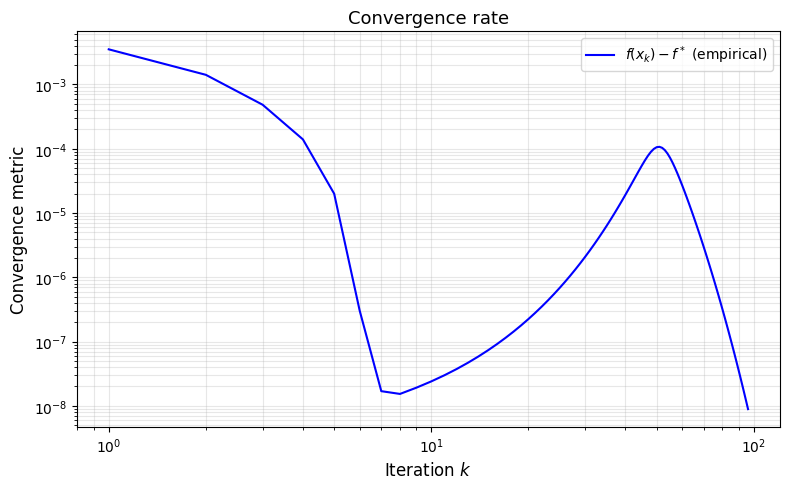

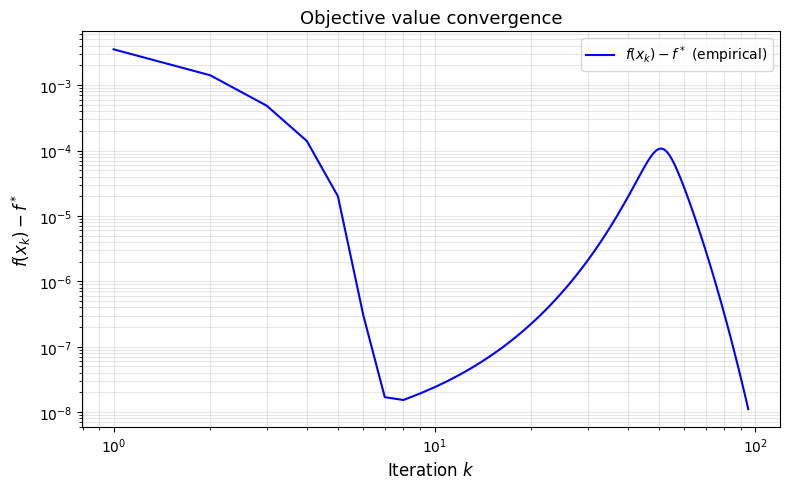

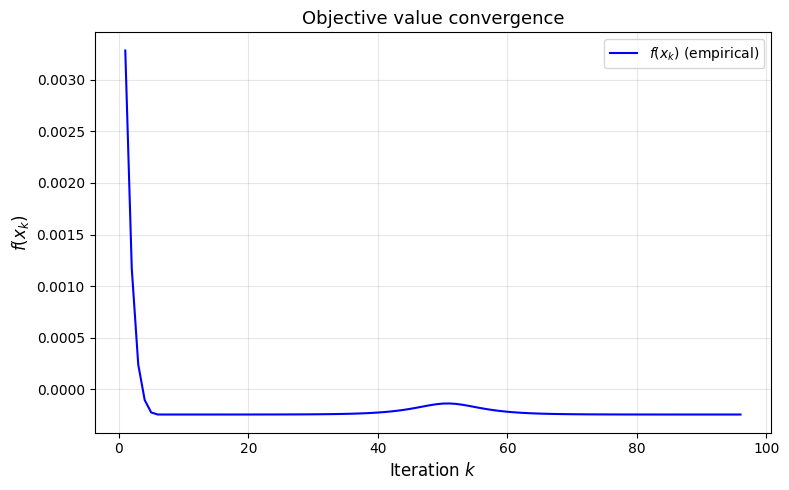

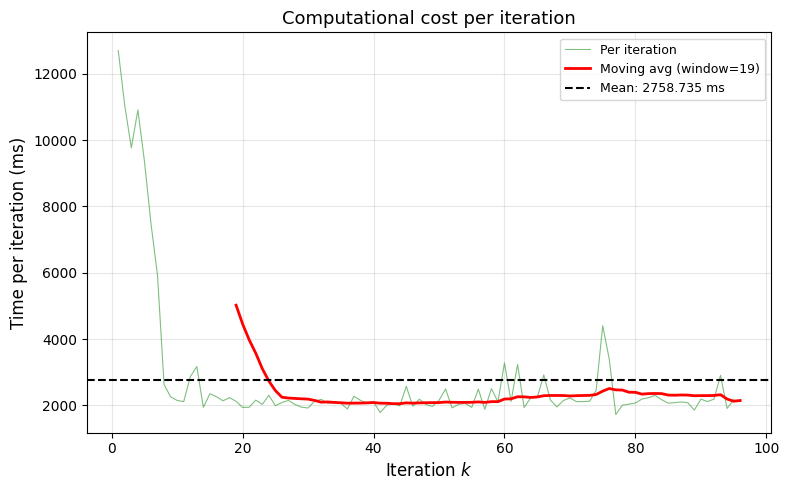

Total time: 264.8386 seconds
Total iterations: 96
Final objective value: -0.000242
Average time per iteration: 2758.7354 ms
Std time per iteration: 2037.1294 ms


In [31]:
# Long-step Interior Point Method (for SMOOTH Markowitz model)
# Note: IPM works on smooth problems, so we use the smooth model

w0 = get_initial_portfolio(data['mu'].shape[0])
mu = data['mu']
sigma = data['sigma']
lam = 0.5
c = 0.01
w_prev = w0
model_non_smooth = NonSmoothMarkowitzModel({
    "mu": mu,
    "sigma": sigma,
    "lam": lam,
    "c": c,
    "w_prev":w_prev
})
model = SmoothMarkowitzModel({
    "mu": mu,
    "sigma": sigma,
    "lam": lam,
})
L = model.lipschitz_constant()



w0 = get_initial_portfolio(data['mu'].shape[0] , method='random')

# Initial point (strictly feasible)

# Long-step IPM
method_longstep = InteriorPointMethodLongStep({
    'epsilon': 1e-6,        # Final accuracy
    'tau': 0.25,            # Target proximity parameter
    'theta': 0.2,           # Barrier decrease factor (any value in (0,1))
    'mu0': 1.0,             # Initial barrier parameter
    'max_iter': 200,        # Max outer iterations
    'max_inner_iter': 50,   # Max inner Newton steps per outer iteration
}, ValuePerformanceIndicator_with_ref(f_ref=f_ref))

result_longstep = method_longstep.optimize(model_non_smooth, w0)

print(f"\nConverged: {result_longstep['converged']}")
print(f"Outer iterations: {result_longstep['iterations']}")
print(f"Final objective value: {result_longstep['value']:.8f}")
print(f"Gap to optimal: {result_longstep['value'] - f_ref:.2e}")

# Plot convergence
plot_convergence(result_longstep, method_name="InteriorPoint_LongStep", 
                 save_dir="../figures", metric_used='function_with_ref', f_ref=f_ref)